In [1]:
import itertools
import numpy as np
import gurobipy as gp
from gurobipy import GRB




In [85]:
def optimal_min_cut_balanced(n, edges):
    model = gp.Model()
    model.Params.OutputFlag = 0

    # x_i in {0,1}
    x = model.addVars(n, vtype=GRB.BINARY, name="x")

    # c_e = 1 if hyperedge e is cut
    c = model.addVars(len(edges), vtype=GRB.BINARY, name="cut")

    target_ones = (n + 1) // 2
    # exact balance: half the vertices in partition 1
    model.addConstr(gp.quicksum(x[i] for i in range(n)) ==target_ones,name="balance")

    # AoN cut constraints
    for e_idx, edge in enumerate(edges):
        for u, v in itertools.combinations(edge, 2):
            #enforce that the edge is cut if vertexes in different partitions
            model.addConstr(c[e_idx] >= x[u] - x[v])
            model.addConstr(c[e_idx] >= x[v] - x[u])

    # minimize total number of cut hyperedges
    objective = gp.quicksum(c[e_idx] for e_idx in range(len(edges)))

    model.setObjective(objective, GRB.MINIMIZE)

    model.optimize()

    assert model.Status == GRB.OPTIMAL, f"Gurobi did not prove optimality. Status = {model.Status}"
    # print(x)
    # print(c)
    x_opt = np.array([
        int(round(x[i].X))
        for i in range(n)
    ])
    cut_opt = np.array([int(round(c[e_idx].X)) for e_idx in range(len(edges))])


    return x_opt, cut_opt, model.ObjVal

In [70]:
n = 6

edges = [
    (0, 1, 2),
    (3, 4, 5),
    (0, 3)
]
mini_example=[n,edges]

In [71]:
x_opt, cut_opt, obj = optimal_min_cut_balanced(mini_example[0], mini_example[1])

print("Optimal partition:", x_opt)
print("Cut indicators:", cut_opt)
print("Optimal cost:", obj)

Optimal partition: [0 0 0 1 1 1]
Cut indicators: [0 0 1]
Optimal cost: 1.0


In [72]:
def get_edge_list(P):
    edges=[]
    for idx in range(P.shape[1]):
        #indices that are not 0
        edge = tuple(np.flatnonzero(P[:,idx]))
        edges.append(edge)
    return edges

In [73]:
import os
os.getcwd()

'/Users/stevehalley/Code/Github/QuantumHypergraphPartitioning'

In [78]:
import glob
poisson_types = [
    "poisson_16_12_3",
    "poisson_16_12_4",
    "poisson_16_12_5"
]

poisson_results = []

for graph_type in poisson_types:
    p_folder = f"data/{graph_type}/P"
    p_files = sorted(glob.glob(f"{p_folder}/*.npy"))
    for p_file in p_files:
        instance = os.path.splitext(os.path.basename(p_file))[0]
        P = np.load(p_file)
        n = P.shape[0]
        edges = get_edge_list(P)

        x_opt, cut_opt, optimal_cost = optimal_min_cut_balanced(n, edges)

        poisson_results.append({
            "dataset": graph_type,
            "instance": instance,
            "n_vertices": n,
            "n_edges": len(edges),
            "optimal_partition":
                "".join(map(str, x_opt)),
            "optimal_cost": optimal_cost,
            "cut_indicators":
                "".join(map(str, cut_opt))
        })

        print(
            graph_type,
            instance,
            "cost =",
            optimal_cost
        )

poisson_16_12_3 01 cost = 6.0
15
15
12
poisson_16_12_3 02 cost = 6.0
16
16
12
poisson_16_12_3 03 cost = 8.0
16
16
12
poisson_16_12_3 04 cost = 10.0
16
16
12
poisson_16_12_3 05 cost = 7.0
16
16
12
poisson_16_12_3 06 cost = 10.0
16
16
12
poisson_16_12_3 07 cost = 8.0
16
16
12
poisson_16_12_3 08 cost = 7.0
15
15
12
poisson_16_12_3 09 cost = 9.0
16
16
12
poisson_16_12_3 10 cost = 7.0
16
16
12
poisson_16_12_3 11 cost = 7.0
16
16
12
poisson_16_12_3 12 cost = 7.0
15
15
12
poisson_16_12_3 13 cost = 10.0
16
16
12
poisson_16_12_3 14 cost = 7.0
16
16
12
poisson_16_12_3 15 cost = 8.0
16
16
12
poisson_16_12_3 16 cost = 8.0
16
16
12
poisson_16_12_3 17 cost = 5.0
16
16
12
poisson_16_12_3 18 cost = 7.0
16
16
12
poisson_16_12_3 19 cost = 7.0
15
15
12
poisson_16_12_3 20 cost = 6.0
15
15
12
poisson_16_12_4 01 cost = 10.0
16
16
12
poisson_16_12_4 02 cost = 10.0
16
16
12
poisson_16_12_4 03 cost = 10.0
16
16
12
poisson_16_12_4 04 cost = 10.0
16
16
12
poisson_16_12_4 05 cost = 9.0
16
16
12
poisson_16_12_4 06

In [75]:
import pandas as pd
poisson_df = pd.DataFrame(poisson_results)

poisson_df.to_csv(
    "poisson_exact_results.csv",
    index=False
)

In [86]:
import os
import glob
import numpy as np
import pandas as pd

folder = "data/congress-bills/numpy_20"
files = sorted(glob.glob(f"{folder}/*.npy"))

congress_results = []

for file in files:

    P = np.load(file)
    instance = os.path.splitext(os.path.basename(file))[0]

    n = P.shape[0]
    edges = get_edge_list(P)

    x_opt, cut_opt, optimal_cost = (optimal_min_cut_balanced(n, edges))

    congress_results.append({
        "dataset": "congress-bills",
        "instance": instance,
        "n_vertices": n,
        "n_edges": len(edges),
        "target_ones": (n + 1) // 2,
        "optimal_partition": "".join(map(str, x_opt)),
        "optimal_cost": optimal_cost,
        "cut_indicators": "".join(map(str, cut_opt))
    })

    print(
        instance,
        "n =", n,
        "m =", len(edges),
        "target ones =", (n + 1) // 2,
        "cost =", optimal_cost
    )

    print("partition:", x_opt)
    print("cut indicators:", cut_opt)
    print()

congress-bills_01 n = 2 m = 1 target ones = 1 cost = 1.0
partition: [1 0]
cut indicators: [1]

congress-bills_02 n = 4 m = 2 target ones = 2 cost = 0.0
partition: [1 0 1 0]
cut indicators: [0 0]

congress-bills_03 n = 5 m = 3 target ones = 3 cost = 0.0
partition: [1 0 0 1 1]
cut indicators: [0 0 0]

congress-bills_04 n = 10 m = 7 target ones = 5 cost = 1.0
partition: [0 1 0 0 0 1 1 1 0 1]
cut indicators: [0 0 0 1 0 0 0]

congress-bills_05 n = 9 m = 11 target ones = 5 cost = 0.0
partition: [0 1 0 1 0 1 0 1 1]
cut indicators: [0 0 0 0 0 0 0 0 0 0 0]

congress-bills_06 n = 14 m = 8 target ones = 7 cost = 0.0
partition: [1 1 1 0 0 0 0 0 0 1 1 1 0 1]
cut indicators: [0 0 0 0 0 0 0 0]

congress-bills_07 n = 18 m = 10 target ones = 9 cost = 0.0
partition: [0 1 0 1 1 1 0 1 1 1 0 1 0 0 0 0 0 1]
cut indicators: [0 0 0 0 0 0 0 0 0 0]

congress-bills_08 n = 4 m = 2 target ones = 2 cost = 0.0
partition: [1 1 0 0]
cut indicators: [0 0]

congress-bills_09 n = 14 m = 11 target ones = 7 cost = 2.0
part

In [88]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt


def get_edge_list(P):
    edges = []

    for e_idx in range(P.shape[1]):
        edge = tuple(
            int(v)
            for v in np.flatnonzero(P[:, e_idx] != 0)
        )
        edges.append(edge)

    return edges


def draw_hypergraph_incidence(P, title):
    edges = get_edge_list(P)

    G = nx.Graph()

    vertex_nodes = [f"v{i}" for i in range(P.shape[0])]
    edge_nodes = [f"e{j}" for j in range(P.shape[1])]

    G.add_nodes_from(vertex_nodes, bipartite=0)
    G.add_nodes_from(edge_nodes, bipartite=1)

    for e_idx, edge in enumerate(edges):
        for v in edge:
            G.add_edge(f"v{v}", f"e{e_idx}")

    pos = nx.bipartite_layout(G, vertex_nodes)

    plt.figure(figsize=(8, 5))

    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=vertex_nodes,
        node_shape="o"
    )

    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=edge_nodes,
        node_shape="s"
    )

    nx.draw_networkx_edges(G, pos)
    nx.draw_networkx_labels(G, pos)

    plt.title(title)
    plt.axis("off")
    plt.show()

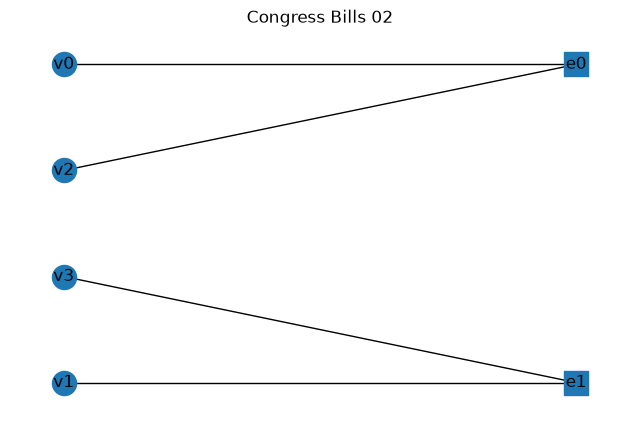

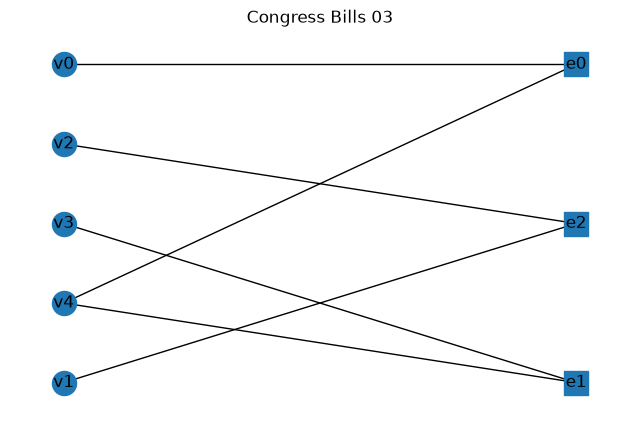

In [91]:
P1 = np.load(
    "data/congress-bills/numpy_20/congress-bills_02.npy"
)

P2 = np.load(
    "data/congress-bills/numpy_20/congress-bills_03.npy"
)

draw_hypergraph_incidence(P1, "Congress Bills 02")
draw_hypergraph_incidence(P2, "Congress Bills 03")

In [ ]:
# congress-bills_03 n = 5 m = 3 target ones = 3 cost = 0.0
# partition: [1 0 0 1 1]
# cut indicators: [0 0 0]

In [92]:

congress_df = pd.DataFrame(congress_results)

congress_df.to_csv(
    "congress_bills_exact_results.csv",
    index=False
)